# EV-bucket diagnostics for the selected pooled model

## Does higher estimated EV translate into better realized performance?

This robustness notebook uses the same selected model as notebook 01: one pooled all-league logistic regression, trained on the previous two seasons before each test season, with `L2 = 100`.

The purpose is not to find a new threshold. The purpose is to test whether the selected model's estimated expected value ranks opportunities in a sensible way across fixed, prespecified EV buckets.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    build_execution_candidates,
    build_research_dataset,
    ev_bucket_summary,
    run_pooled_rolling_walk_forward,
)
from football_edge.config import EV_BUCKET_EDGES, EV_BUCKET_LABELS, RAW_DATA_DIR
from football_edge.data import discover_datasets
from football_edge.plotting import (
    SOURCE_LABELS,
    plot_ev_bucket_counts,
    plot_ev_bucket_diagnostics,
)

pd.options.display.float_format = "{:,.2f}".format
plt.style.use("seaborn-v0_8-whitegrid")

SELECTED_L2 = 100.0
TRAINING_WINDOW = 2
MODEL_NAME = "Pooled L2 = 100"


## 1. Research design

The probabilities are generated by the selected strategy model from notebook 01:

- one unified model across all leagues;
- exactly the previous two seasons used for training before each test season;
- `L2 = 100`, selected in notebook 02 as the most stable fitted regularization setting;
- the same leakage-safe shifted team-form features and market log-odds.

Every valid quoted price is retained as a candidate. Candidate inclusion does not depend on the 3% primary betting threshold or on future closing-quote availability. Closing prices contribute only to the CLV diagnostic when available.

The buckets are fixed before examining their outcomes:

- `<0%`
- `0-2%`
- `2-4%`
- `4-6%`
- `6-10%`
- `>=10%`

A useful ranking signal should generally show better realized ROI and/or CLV as estimated EV increases. Exact monotonicity is not expected in every bucket because realized betting returns are noisy and high-EV buckets can be sparse.


In [2]:
datasets = discover_datasets(RAW_DATA_DIR)
all_matches = build_research_dataset(datasets)
predictions, fold_coefficients = run_pooled_rolling_walk_forward(
    all_matches,
    l2=SELECTED_L2,
    model_name=MODEL_NAME,
    training_window=TRAINING_WINDOW,
)
candidates = build_execution_candidates(predictions, include_closing_prices=True)
bucket_results = ev_bucket_summary(candidates)

sample_design = (
    predictions.groupby("season")
    .agg(
        test_matches=("date", "size"),
        leagues=("league", "nunique"),
        training_seasons=("training_seasons", "first"),
        training_matches=("training_matches", "first"),
        train_end_date=("train_end_date", "first"),
        test_start_date=("test_start_date", "first"),
    )
    .reset_index()
)

assert list(EV_BUCKET_LABELS) == ["<0%", "0-2%", "2-4%", "4-6%", "6-10%", ">=10%"]
assert candidates["model_probability"].between(0, 1).all()
assert (predictions["train_end_date"] < predictions["test_start_date"]).all()

sample_design


,season,test_matches,leagues,training_seasons,training_matches,train_end_date,test_start_date
0,23_24,1407,4,"21_22,22_23",2813,2023-06-04 20:00:00,2023-08-18 18:30:00
1,24_25,1407,4,"22_23,23_24",2814,2024-06-02 17:00:00,2024-08-23 18:00:00
2,25_26,1407,4,"23_24,24_25",2814,2025-05-25 20:00:00,2025-08-22 20:00:00


## 2. Candidate and CLV coverage

Candidate counts differ because quote coverage varies by source. CLV coverage is reported separately: a missing closing quote does not remove an otherwise valid quoted candidate.

`MaxC>2.5` is included as a closing market maximum sensitivity. It has no later reference quote, so CLV is undefined for that source and it should not be interpreted as a normally executable pre-closing strategy.


In [3]:
candidate_coverage = (
    candidates.groupby("execution_source")
    .agg(
        candidates=("date", "size"),
        first_match=("date", "min"),
        last_match=("date", "max"),
        clv_observations=("closing_odds", "count"),
    )
    .reset_index()
)
candidate_coverage["clv_coverage_pct"] = (
    candidate_coverage["clv_observations"] / candidate_coverage["candidates"] * 100
)
candidate_coverage["execution_source"] = candidate_coverage[
    "execution_source"
].map(SOURCE_LABELS)
candidate_coverage

,execution_source,candidates,first_match,last_match,clv_observations,clv_coverage_pct
0,Market average,4221,2023-08-18 18:30:00,2026-05-24 20:00:00,4221,100.00
1,Closing market maximum,4221,2023-08-18 18:30:00,2026-05-24 20:00:00,0,0.00
2,Market maximum,4221,2023-08-18 18:30:00,2026-05-24 20:00:00,4221,100.00
3,Bet365,4221,2023-08-18 18:30:00,2026-05-24 20:00:00,4221,100.00
4,Betfair Exchange,2709,2024-08-23 20:30:00,2026-05-24 20:00:00,2705,99.85
5,Pinnacle,3476,2023-08-18 18:30:00,2026-01-15 19:45:00,3473,99.91


## 3. Estimated EV versus realized ROI

Bars show realized flat-stake ROI. The dashed line shows the model's mean estimated EV in the same bucket. Labels report the number of candidate matches. Large gaps between estimated and realized values indicate probability miscalibration, price noise, or both.

In [4]:
bucket_table = bucket_results[
    [
        "execution_source",
        "ev_bucket",
        "candidates",
        "mean_estimated_ev_pct",
        "realized_roi_pct",
        "clv_observations",
        "mean_clv_pct",
    ]
].copy()
bucket_table["execution_source"] = bucket_table["execution_source"].map(SOURCE_LABELS)
bucket_table

,execution_source,ev_bucket,candidates,mean_estimated_ev_pct,realized_roi_pct,clv_observations,mean_clv_pct
0,Market average,<0%,4025,-5.84,-3.93,4025,-0.62
1,Market average,0-2%,152,0.78,-7.07,152,-1.07
2,Market average,2-4%,35,2.71,0.71,35,-0.77
3,Market average,4-6%,6,5.19,6.00,6,-0.49
4,Market average,6-10%,2,8.23,-34.00,2,-1.92
5,Market average,>=10%,1,10.20,-100.00,1,-2.26
6,Closing market maximum,2-4%,359,2.88,5.77,0,NaN
7,Closing market maximum,6-10%,366,7.68,11.80,0,NaN
8,Closing market maximum,0-2%,525,0.99,-0.95,0,NaN
9,Closing market maximum,<0%,2439,-5.18,0.06,0,NaN


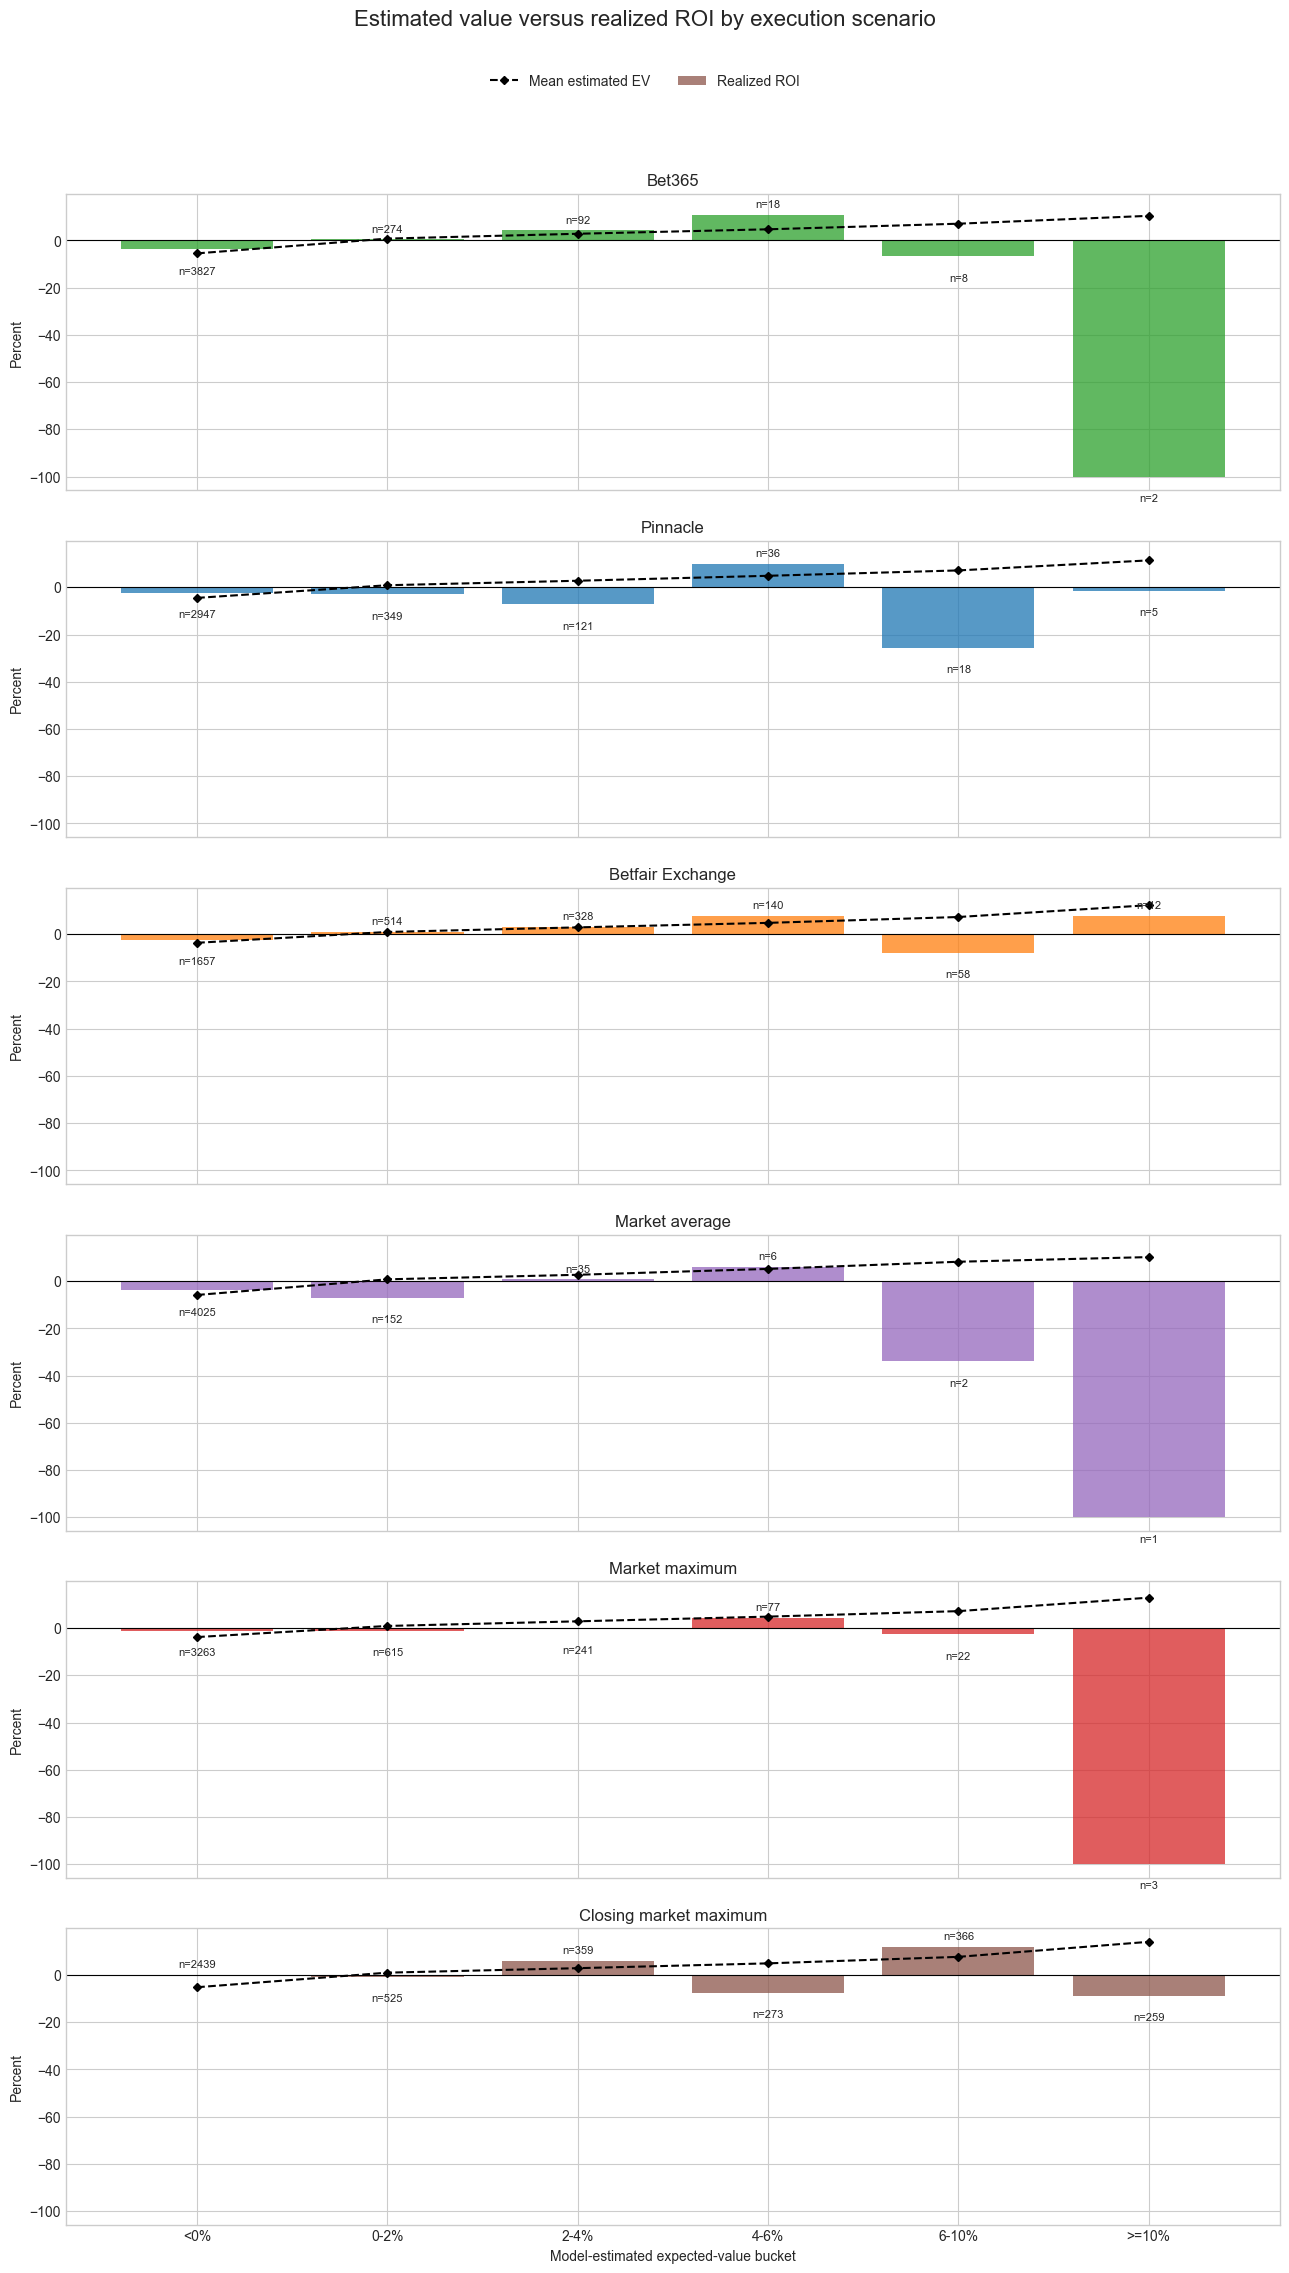

In [5]:
plot_ev_bucket_diagnostics(bucket_results)
plt.show()

## 4. Candidate distribution across EV buckets

This chart reports how many match-price observations fall into each positive-EV bucket for every execution scenario. The `<0%` bucket is intentionally excluded from this visualization because its much larger count would compress the economically relevant positive-EV buckets; it remains included in the underlying table and ROI diagnostic. These are candidate matches rather than bets selected by the primary 3% rule. Sparse high-EV buckets should be interpreted cautiously.

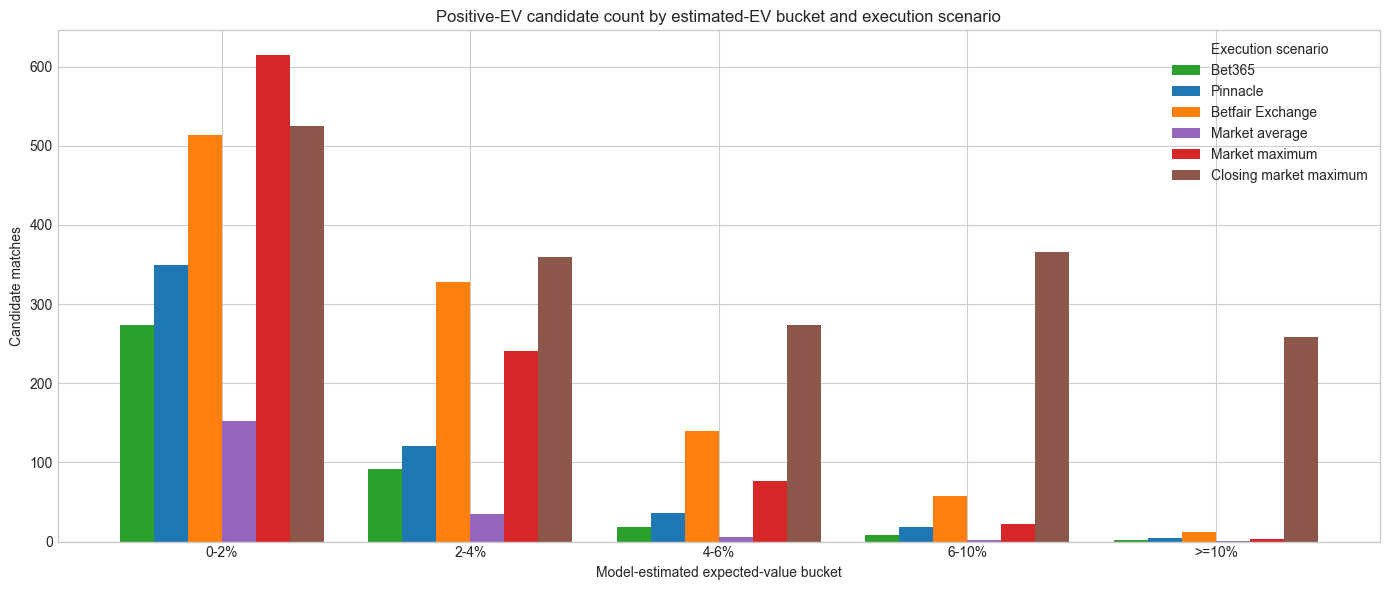

In [6]:
plot_ev_bucket_counts(bucket_results, include_negative=False)
plt.show()

## 5. Interpretation framework

The selected model should not be judged by whether one bucket happens to be profitable. The relevant questions are:

1. Does realized ROI improve broadly as estimated EV rises?
2. Does CLV improve in the same direction where CLV is observable?
3. Are the patterns visible across execution sources rather than isolated to one source?
4. Are the highest-EV results supported by adequate sample sizes?

A non-monotonic pattern, negative CLV in high-EV buckets, or large estimated-versus-realized gaps would indicate that the selected model is not ranking opportunities reliably. In that case, changing the betting threshold would not solve the underlying calibration problem.

These buckets are a robustness diagnostic only. Any future threshold or model revision should be chosen inside an inner chronological validation process and evaluated on a new untouched period.

## 6. Conclusion

This notebook applies EV-bucket diagnostics to the main pooled `L2 = 100` strategy rather than to the earlier league-specific baseline. That makes the diagnostic scientifically aligned with the headline model.

The key question is whether higher model-estimated EV corresponds to better realized ROI and CLV. If the pattern is weak, non-monotonic, concentrated in small samples, or paired with negative CLV, then the selected model may be directionally useful as a probability model but not reliable enough to rank betting opportunities. In that case, the correct next step is not threshold hunting; it is improving calibration, adding stronger pre-match features, and validating on genuinely future timestamped data.
